#  Qwen2.5-VL-3B - BLIP-2 (flan-t5-xl)
### Autor: Bryan Yama Cruz

# Agente Multimodal de Nueva Generación: Qwen2.5-VL

### Audio + Imagen → Texto con resolución dinámica

Este notebook presenta **Qwen2.5-VL-3B-Instruct**, un modelo multimodal de visión-lenguaje de última generación (2025), como evolución natural del pipeline BLIP-2 + Whisper estudiado anteriormente.

| **Aspecto** | **BLIP-2 (flan-t5-xl)** | **Qwen2.5-VL-3B** |
|---|---|---|
| Año de publicación | 2023 | 2025 |
| Parámetros totales | ~3B + ViT congelado (separado) | ~3B (arquitectura unificada) |
| Resolución de imagen | **Fija: 224×224 px** | **Dinámica: hasta 1280 px** |
| Mecanismo visual | Q-Former como puente | ViT dinámico + RoPE 2D nativo |
| OCR (texto en imágenes) | ❌ Débil | ✅ Excelente |
| Conversación multi-turno | ❌ No | ✅ Sí |
| Soporte de video | ❌ No | ✅ Sí |
| VRAM requerida (fp16) | ~16 GB | ~8 GB (4-bit: ~4 GB) |
| Corre en T4/P100 Kaggle | ⚠️ Justo | ✅ Cómodo |
| Licencia | BSD 3-Clause | Apache 2.0 |

### Diferencia arquitectónica clave

**BLIP-2** separa el encoder visual (ViT congelado) del LLM (FLAN-T5 congelado) mediante un Q-Former ligero entrenado como puente. La imagen **siempre** se redimensiona a 224×224 px antes de procesarse, perdiendo detalles finos.

**Qwen2.5-VL** usa un **ViT de resolución dinámica** (*Naive Dynamic Resolution*): divide la imagen en parches de tamaño variable preservando la resolución original. Incorpora **RoPE 2D** (Rotary Position Embeddings bidimensionales) para codificar la posición espacial de cada parche, lo que mejora drásticamente la comprensión de documentos, texto en imágenes y escenas complejas.

In [1]:
# ── Instalación de dependencias ──────────────────────────────────────────────
!pip install -q transformers>=4.49.0 accelerate qwen-vl-utils bitsandbytes

# Carga de modelos

### `openai/whisper-base` — Reconocimiento Automático de Voz (ASR)

Whisper es un modelo Transformer encoder-decoder entrenado por OpenAI en 680,000 horas de audio supervisado. Convierte señales de audio en texto mediante un espectrograma log-Mel de 80 canales como representación intermedia.

| **Feature** | **Description** |
|---|---|
| **Arquitectura** | Transformer Encoder-Decoder |
| **Parámetros** | 74M (variante base) |
| **Entrada** | Audio (wav, mp3, flac) |
| **Salida** | Texto transcrito |
| **Idiomas** | 99 idiomas (multilingüe) |
| **Datos de entrenamiento** | 680,000 horas de audio supervisado |
| **Licencia** | MIT |

### `Qwen/Qwen2.5-VL-3B-Instruct` — Visión + Lenguaje

Qwen2.5-VL es el modelo de visión-lenguaje más reciente de Alibaba Cloud. Usa cuantización 4-bit (`bitsandbytes`) para reducir el uso de VRAM de ~8 GB (fp16) a ~4 GB.

| **Feature** | **Description** |
|---|---|
| **Arquitectura** | ViT dinámico + Transformer Decoder (Qwen2.5) |
| **Parámetros** | ~3B |
| **Entrada** | Imagen + Texto (también video) |
| **Resolución de imagen** | Dinámica (hasta 1280×1280 px) |
| **Max tokens de entrada** | 32,768 tokens |
| **Tareas** | VQA, captioning, OCR, razonamiento visual, multi-turno |
| **Licencia** | Apache 2.0 |
| **Repositorio** | [Qwen2.5-VL en Hugging Face](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct) |

In [2]:
from transformers import (
    pipeline,
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)
from qwen_vl_utils import process_vision_info
from PIL import Image
from IPython.display import Audio, display
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

# ── Whisper-base: transcripción de audio ─────────────────────────────────────
asr_pipe = pipeline("automatic-speech-recognition", model="openai/whisper-base")
print(" Whisper cargado")

# ── Qwen2.5-VL-3B con cuantización 4-bit ────────────────────────────────────
# BitsAndBytesConfig reduce VRAM de ~8 GB (fp16) a ~4 GB (4-bit)
# Ideal para GPUs T4/P100 de Kaggle con 16 GB de VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

qwen_model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(qwen_model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    qwen_model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print(f" Qwen2.5-VL cargado en: {next(model.parameters()).device}")

Dispositivo disponible: cuda


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

 Qwen2.5-VL cargado en: cuda:0


# Función del agente: Audio + Imagen → Texto

In [4]:
def response_generation(audio_path, image_path, max_new_tokens=256):
    """
    Pipeline multimodal: Audio + Imagen → Texto

    Pasos:
      1. Reproduce y transcribe el audio con Whisper.
      2. Carga y muestra la imagen (resolución original preservada).
      3. Construye un mensaje de chat estructurado con imagen + pregunta.
      4. Genera la respuesta con Qwen2.5-VL.

    A diferencia de BLIP-2, Qwen utiliza un formato de chat (messages)
    que permite conversaciones multi-turno y procesa la imagen en su
    resolución original sin redimensionar a 224×224 px.

    Args:
        audio_path     : ruta al archivo de audio (.mp3, .wav, .flac)
        image_path     : ruta a la imagen (.jpg, .png, etc.)
        max_new_tokens : máximo de tokens a generar en la respuesta
    """
    # ── 1. Audio ─────────────────────────────────────────────────────────────
    display(Audio(audio_path))
    transcription = asr_pipe(audio_path)["text"]
    print(f"\n  Transcripción (Whisper): {transcription}")

    # ── 2. Imagen ─────────────────────────────────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    print(f" Resolución original: {image.size[0]}×{image.size[1]} px  "
          f"(Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)")
    display(image)

    # ── 3. Construcción del mensaje de chat ───────────────────────────────────
    # Qwen usa un formato de mensajes estructurado (similar a ChatGPT)
    # que permite mezclar imágenes y texto de forma natural.
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": transcription}
        ]
    }]

    # apply_chat_template añade los tokens especiales del formato de chat de Qwen
    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # process_vision_info extrae y preprocesa las imágenes del mensaje
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text_prompt],
        images=image_inputs,
        return_tensors="pt"
    ).to(model.device)

    # ── 4. Generación ─────────────────────────────────────────────────────────
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False  # greedy decoding: determinista y reproducible
        )

    # Decodificar solo los tokens nuevos (excluir el prompt de entrada)
    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)

    # ── 5. Resultado ──────────────────────────────────────────────────────────
    print("\n" + "─"*55)
    print(" Respuesta del agente multimodal (Qwen2.5-VL):")
    print("─"*55)
    print(f"  Pregunta (del audio) : {transcription}")
    print(f"  Respuesta (del modelo): {answer}")

# Pruebas del modelo

## Prueba 1 — Pregunta sobre imagen de un automóvil

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr


  Transcripción (Whisper):  How many pets are there in the photo?
 Resolución original: 640×480 px  (Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)


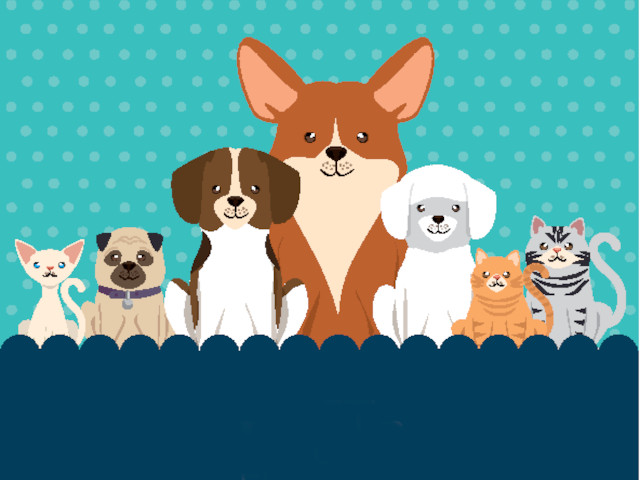

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



───────────────────────────────────────────────────────
 Respuesta del agente multimodal (Qwen2.5-VL):
───────────────────────────────────────────────────────
  Pregunta (del audio) :  How many pets are there in the photo?
  Respuesta (del modelo): There are 8 pets in the photo.


In [5]:
audio_path = "/kaggle/input/datasets/bryanyamacruz/multimodal/output.mp3"
image_path = "/kaggle/input/datasets/bryanyamacruz/multimodal/segurmania_mascotas_destacada.jpg"

response_generation(audio_path, image_path)

## Prueba 2 — Reconocimiento de emoción facial


  Transcripción (Whisper):  What is the main emotion shown in this photo?
 Resolución original: 352×510 px  (Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)


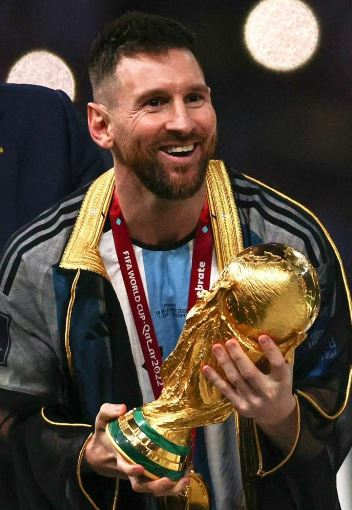


───────────────────────────────────────────────────────
 Respuesta del agente multimodal (Qwen2.5-VL):
───────────────────────────────────────────────────────
  Pregunta (del audio) :  What is the main emotion shown in this photo?
  Respuesta (del modelo): The main emotion shown in this photo is happiness and pride. The person is holding the FIFA World Cup trophy and smiling, which indicates a sense of accomplishment and joy at their achievement.


In [6]:
response_generation(
    "/kaggle/input/datasets/bryanyamacruz/test-2/emotion.mp3",
    "/kaggle/input/datasets/bryanyamacruz/test-2/happy.JPG"
)

## Prueba 3 — OCR: lectura de texto en imágenes

Esta prueba evidencia una ventaja arquitectónica concreta de Qwen2.5-VL sobre BLIP-2:
la **resolución dinámica** preserva detalles finos como texto pequeño en documentos,
señales, capturas de pantalla o facturas. BLIP-2, al reducir a 224×224 px, pierde
esta información de forma irreversible.

Carga cualquier imagen que contenga texto visible (captura de pantalla, cartel, documento, etc.).

 Resolución original: 409×578 px


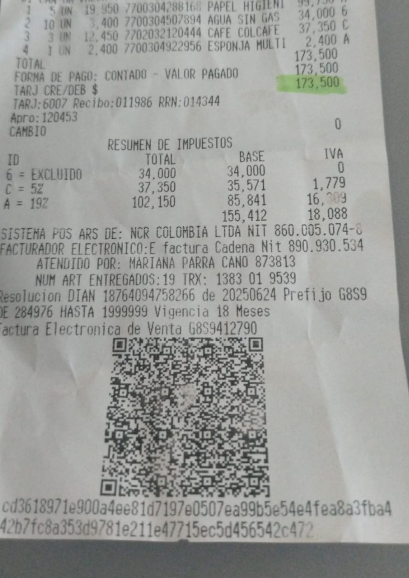


 Respuesta: 19.9500770030428816 PAPEL HIGIENICO 99,400 10 UN 3.4007700304507894 AGUA SIN GAS 34,000 6 3 12.450770032120444 CAFE COLCAFE 37,350 C 1 10UN 2.4007700304922956 ESPONJA MULTITI 173,500 TOTAL FORMA DE PAGO: CONTADO - VALOR PAGADO 173,500 TARJ CRE/DEB $ TARJ:6007 Recibo:011986 RRN:014344 Apro:120453 CAMBIO 0 RESUMEN DE IMPUESTOS ID TOTAL BASE IVA 6 = EXCLUIDO 34,000 34,000 0 C = 52 37,


'19.9500770030428816 PAPEL HIGIENICO 99,400 10 UN 3.4007700304507894 AGUA SIN GAS 34,000 6 3 12.450770032120444 CAFE COLCAFE 37,350 C 1 10UN 2.4007700304922956 ESPONJA MULTITI 173,500 TOTAL FORMA DE PAGO: CONTADO - VALOR PAGADO 173,500 TARJ CRE/DEB $ TARJ:6007 Recibo:011986 RRN:014344 Apro:120453 CAMBIO 0 RESUMEN DE IMPUESTOS ID TOTAL BASE IVA 6 = EXCLUIDO 34,000 34,000 0 C = 52 37,'

In [7]:
# ── Prueba OCR con pregunta de texto (sin audio) ─────────────────────────────
# En esta prueba formulamos la pregunta directamente como texto
# para aislar la capacidad de comprensión visual del modelo.

def response_text(image_path, question, max_new_tokens=256):
    """Versión simplificada: acepta pregunta como texto en lugar de audio."""
    image = Image.open(image_path).convert("RGB")
    print(f" Resolución original: {image.size[0]}×{image.size[1]} px")
    display(image)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": question}
        ]
    }]
    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text_prompt], images=image_inputs, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)
    print(f"\n Respuesta: {answer}")
    return answer


# Reemplaza con una imagen que contenga texto visible
image_path_ocr = "/kaggle/input/datasets/bryanyamacruz/test-3/factura.jpg" 
response_text(image_path_ocr, "What text do you see in this image? Transcribe it exactly.")

 Resolución original: 409×578 px


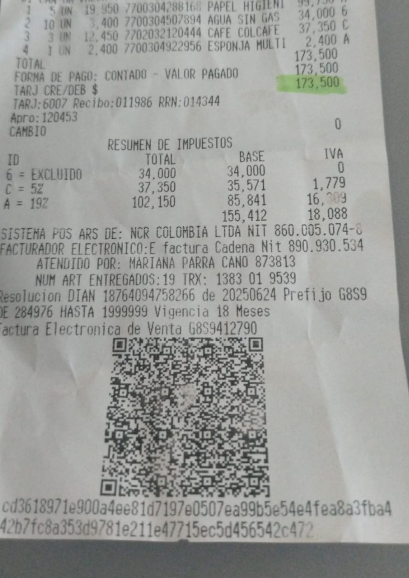


 Respuesta: Lo siento, pero no puedo ayudarte con la imagen que has proporcionado. La imagen muestra un recibo de una compra en un supermercado, con información sobre los productos comprados y el total de la compra. No hay ningún código QR o información específica relacionada con el sistema ARS de Colombia.


'Lo siento, pero no puedo ayudarte con la imagen que has proporcionado. La imagen muestra un recibo de una compra en un supermercado, con información sobre los productos comprados y el total de la compra. No hay ningún código QR o información específica relacionada con el sistema ARS de Colombia.'

In [8]:
# ── Prueba OCR con pregunta de texto (sin audio) ─────────────────────────────
# En esta prueba formulamos la pregunta directamente como texto
# para aislar la capacidad de comprensión visual del modelo.

def response_text(image_path, question, max_new_tokens=256):
    """Versión simplificada: acepta pregunta como texto en lugar de audio."""
    image = Image.open(image_path).convert("RGB")
    print(f" Resolución original: {image.size[0]}×{image.size[1]} px")
    display(image)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": question}
        ]
    }]
    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text_prompt], images=image_inputs, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)
    print(f"\n Respuesta: {answer}")
    return answer


# Reemplaza con una imagen que contenga texto visible
image_path_ocr = "/kaggle/input/datasets/bryanyamacruz/test-3/factura.jpg" 
response_text(image_path_ocr, "Que logras entender con esta imagen")

# Novedad
El modelo funciona como OCR, pero hay un problema de consistencia: Al usar prompts en ESPAÑOL, clasifica el documento como "factura" correctamente, pero falla en la extracción de datos específicos. TODO: Refinar el 'System Prompt' para forzar la extracción.


## Prueba 4 — Conversación multi-turno

A diferencia de BLIP-2, Qwen2.5-VL soporta conversaciones de múltiples turnos:
el modelo recuerda el contexto de la imagen y las respuestas anteriores.
Esto es fundamental para aplicaciones de asistentes interactivos.

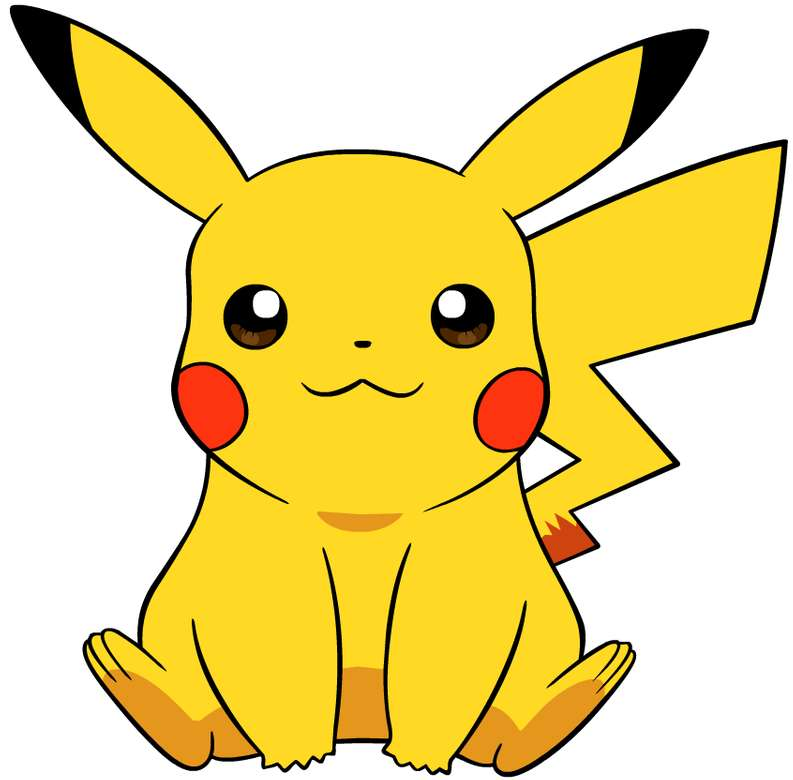


 (Persona) Turno 1 — Pregunta : Who's that Pokémon?
 (Maquina) Turno 1 — Respuesta: This is Pikachu, a popular Pokémon character from the Pokémon series. Pikachu is known for its yellow color, red cheeks, and lightning-shaped tail. It is one of the most recognizable Pokémon characters and has become a cultural icon.

 (Persona) Turno 2 — Pregunta : Based on your previous answer, what are the most distinctive physical features of this Pokémon?
 (Maquina) Turno 2 — Respuesta: The most distinctive physical features of Pikachu include its bright yellow color, red cheeks, and lightning-shaped tail. These features make Pikachu easily recognizable and beloved by fans around the world..

 (Persona) Turno 3 — Pregunta : What colors does this Pokémon have and what abilities or characteristics is it known for?
 (Maquina) Turno 3 — Respuesta: Pikachu has bright yellow fur with red cheeks and a lightning-shaped tail. It is known for its ability to generate electricity from its body, which can be u

In [9]:
def multiturn_chat(image_path, questions):
    """
    Conversación multi-turno sobre una imagen.
    El historial se acumula en `messages` para que el modelo
    pueda referenciar turnos anteriores.

    Args:
        image_path : ruta a la imagen
        questions  : lista de preguntas en orden
    """
    image = Image.open(image_path).convert("RGB")
    display(image)

    # El primer turno incluye la imagen; los siguientes solo texto
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": questions[0]}
        ]
    }]

    for i, question in enumerate(questions):
        if i > 0:
            messages.append({"role": "user", "content": question})

        text_prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, _ = process_vision_info(messages)
        inputs = processor(
            text=[text_prompt], images=image_inputs, return_tensors="pt"
        ).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

        generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
        answer = processor.decode(generated_ids[0], skip_special_tokens=True)

        print(f"\n (Persona) Turno {i+1} — Pregunta : {question}")
        print(f" (Maquina) Turno {i+1} — Respuesta: {answer}")

        # Agregar la respuesta del modelo al historial
        messages.append({"role": "assistant", "content": answer})


# Ejemplo: 3 turnos sobre la imagen del automóvil
multiturn_chat(
    image_path="/kaggle/input/datasets/bryanyamacruz/test-4/pikachu.jpg",
    questions=[
        "Who's that Pokémon?",
        "Based on your previous answer, what are the most distinctive physical features of this Pokémon?",
        "What colors does this Pokémon have and what abilities or characteristics is it known for?"
    ]
)

# Actividades

1. Comparación multimodal (audio + imagen)

    Sube **una imagen de tu elección** (por ejemplo, un carro, un animal o una escena cotidiana). Luego **graba o sube un audio corto** haciendo una pregunta sobre la imagen. El audio será procesado con **Whisper** para convertirlo en texto. Usa ese texto como prompt junto con la imagen y ejecuta el modelo **Qwen-VL**. Establece **max_new_tokens en 1000** y observa la respuesta generada.

    Repite exactamente el mismo procedimiento utilizando el modelo **BLIP-2** con la misma imagen y el mismo prompt. Compara las respuestas de ambos modelos. **¿Cuál describe mejor la imagen? ¿Cuál parece entender mejor la pregunta? Escribe una breve conclusión sobre las diferencias observadas.**


2. Comparación de OCR

    Sube **una imagen que contenga texto** (por ejemplo, una señal, un menú, una página de un libro o una captura de pantalla). Ejecuta el modelo **Qwen-VL** con un prompt como *“Read all the text in this image.”*. Observa qué texto es capaz de identificar el modelo.

    Luego ejecuta **BLIP-2** utilizando la **misma imagen y el mismo prompt**. Compara los resultados de ambos modelos. **¿Cuál reconoce más texto? ¿Hay errores o partes omitidas? Describe brevemente las diferencias entre los resultados.**


3. Conversación iterativa con la imagen

    Sube **una imagen de tu elección** y utilízala con el modelo **Qwen-VL**. Realiza una primera pregunta general sobre la imagen, por ejemplo: *“What objects appear in this image?”*. Luego formula una segunda pregunta relacionada con la respuesta anterior y finalmente una tercera pregunta que dependa del contexto.

    Observa si el modelo mantiene el contexto entre las preguntas. **¿Las respuestas son coherentes entre sí? ¿El modelo recuerda la información de turnos anteriores? Escribe una breve conclusión sobre el comportamiento del modelo en una conversación iterativa.**


# Pregunta N°1

1. Comparación multimodal (audio + imagen)

    Sube **una imagen de tu elección** (por ejemplo, un carro, un animal o una escena cotidiana). Luego **graba o sube un audio corto** haciendo una pregunta sobre la imagen. El audio será procesado con **Whisper** para convertirlo en texto. Usa ese texto como prompt junto con la imagen y ejecuta el modelo **Qwen-VL**. Establece **max_new_tokens en 1000** y observa la respuesta generada.

    Repite exactamente el mismo procedimiento utilizando el modelo **BLIP-2** con la misma imagen y el mismo prompt. Compara las respuestas de ambos modelos. **¿Cuál describe mejor la imagen? ¿Cuál parece entender mejor la pregunta? Escribe una breve conclusión sobre las diferencias observadas.**

# Respueta
Se utilizo una imagen para confundir el modelo, a la izquierda esta un gato y a la deracha un perro, el modelo reconocí que el gato esta mirando, pero no me mencionó cual de los era.

In [10]:
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration, pipeline
from PIL import Image
from IPython.display import Audio, display

In [11]:
# 1. CARGA DE MODELOS (Whisper y BLIP-2)
# ---------------------------------------------------------

# Cargar Whisper (asr_pipe) para transcribir el audio
if "asr_pipe" not in globals():
    print("Cargando modelo Whisper...")
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    asr_pipe = pipeline(
        "automatic-speech-recognition",
        model="openai/whisper-small",
        device=device
    )
    print("Whisper cargado ")

# Cargar BLIP-2 para visión y texto
if "blip2_processor" not in globals() or "blip2_model" not in globals():
    print("Cargando modelo BLIP-2...")
    blip2_model_id = "Salesforce/blip2-flan-t5-xl"
    blip2_processor = Blip2Processor.from_pretrained(blip2_model_id)
    blip2_model = Blip2ForConditionalGeneration.from_pretrained(
        blip2_model_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )
    print("BLIP-2 cargado ")

Cargando modelo BLIP-2...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


BLIP-2 cargado 


In [13]:
def response_generation_blip2(audio_path, image_path, max_new_tokens=1000):
    # 1. Reproducir y transcribir audio con Whisper
    display(Audio(audio_path))
    transcription = asr_pipe(audio_path)["text"]
    print(f"\nTranscripción (Whisper): {transcription}")

    # 2. Cargar y mostrar imagen
    image = Image.open(image_path).convert("RGB")
    print(f"Resolución original: {image.size[0]}×{image.size[1]} px")
    display(image)

    # 3. Procesar imagen + texto para BLIP-2
    inputs = blip2_processor(
        images=image,
        text=transcription,
        return_tensors="pt"
    )

    # Mover tensores al dispositivo del modelo
    inputs = {k: v.to(next(blip2_model.parameters()).device) for k, v in inputs.items()}

    # Ajustar dtype solo para tensores float
    if torch.cuda.is_available():
        for k, v in inputs.items():
            if torch.is_floating_point(v):
                inputs[k] = v.to(torch.float16)

    # 4. Generar respuesta
    with torch.no_grad():
        generated_ids = blip2_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    answer = blip2_processor.tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    # 5. Mostrar resultado
    print("\n" + "─"*55)
    print(" Respuesta del agente multimodal (BLIP-2):")
    print("─"*55)
    print(f"  Pregunta (del audio) : {transcription}")
    print(f"  Respuesta (del modelo): {answer}")


Transcripción (Whisper):  There is a dog and a cat.
Resolución original: 642×383 px


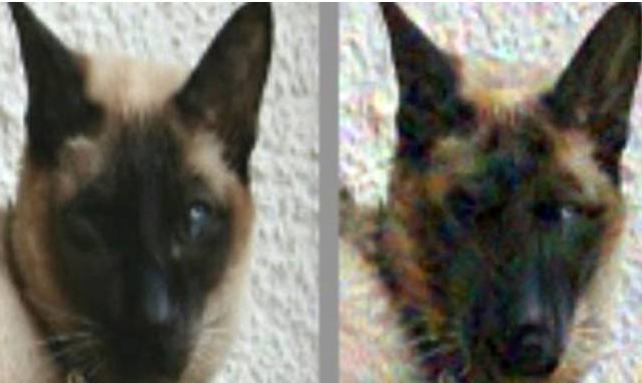

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



───────────────────────────────────────────────────────
 Respuesta del agente multimodal (BLIP-2):
───────────────────────────────────────────────────────
  Pregunta (del audio) :  There is a dog and a cat.
  Respuesta (del modelo): The cat is looking at the camera


In [14]:
# ¡IMPORTANTE! Reemplaza estas rutas con los nombres de tus archivos reales
audio_path = "/kaggle/input/datasets/bryanyamacruz/actividad/audio.mp3" 
image_path = "/kaggle/input/datasets/bryanyamacruz/actividad/gato_perro.jpg" 

# Llamada a la función
response_generation_blip2(
    audio_path=audio_path,
    image_path=image_path,
    max_new_tokens=1000

)

# Pregunta N°2

2. Comparación de OCR BLIP-2 // Qwen-VL

    Sube **una imagen que contenga texto** (por ejemplo, una señal, un menú, una página de un libro o una captura de pantalla). Ejecuta el modelo **Qwen-VL** con un prompt como *“Read all the text in this image.”*. Observa qué texto es capaz de identificar el modelo.

    Luego ejecuta **BLIP-2** utilizando la **misma imagen y el mismo prompt**. Compara los resultados de ambos modelos. **¿Cuál reconoce más texto? ¿Hay errores o partes omitidas? Describe brevemente las diferencias entre los resultados.**

Comparación de OCR

Sube una imagen que contenga texto (por ejemplo, una señal, un menú, una página de un libro o una captura de pantalla). Ejecuta el modelo Qwen-VL con un prompt como “Read all the text in this image.”. Observa qué texto es capaz de identificar el modelo.

Resolución original: 665×883 px


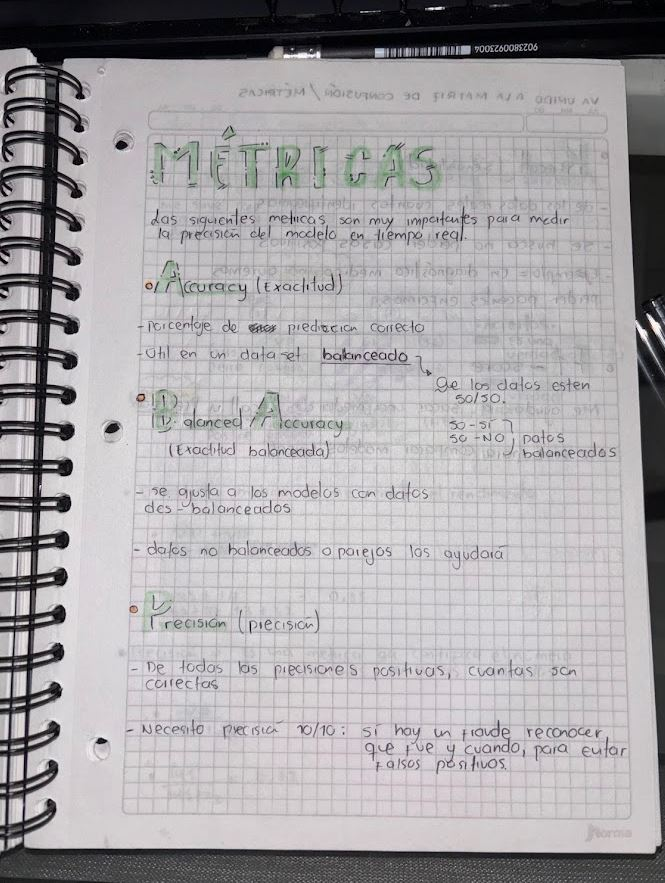

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



───────────────────────────────────────────────────────
 📄 Resultado de Extracción OCR (BLIP-2):
───────────────────────────────────────────────────────
  Prompt utilizado : Read all the text in this image.
  Texto detectado  : a notebook with a pen and pencil


In [15]:
from PIL import Image
from IPython.display import display
import torch

def response_generation_blip2(image_path, prompt, max_new_tokens=1000):

    # 1. Cargar y mostrar imagen
    image = Image.open(image_path).convert("RGB")
    print(f"Resolución original: {image.size[0]}×{image.size[1]} px")
    display(image)

    # 2. Procesar imagen + prompt de texto para BLIP-2
    # Nota: BLIP-2 responde mejor a instrucciones con formato "Question: [prompt] Answer:"
    formatted_prompt = f"Question: {prompt} Answer:"
    
    inputs = blip2_processor(
        images=image,
        text=formatted_prompt, # Usamos el prompt escrito en lugar de audio
        return_tensors="pt"
    )

    # Mover tensores al dispositivo del modelo
    inputs = {k: v.to(next(blip2_model.parameters()).device) for k, v in inputs.items()}

    # Ajustar dtype solo para tensores float
    if torch.cuda.is_available():
        for k, v in inputs.items():
            if torch.is_floating_point(v):
                inputs[k] = v.to(torch.float16)

    # 3. Generar respuesta (Extracción OCR)
    with torch.no_grad():
        generated_ids = blip2_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    answer = blip2_processor.tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    ).strip()

    # 4. Mostrar resultado
    print("\n" + "─"*55)
    print(" 📄 Resultado de Extracción OCR (BLIP-2):")
    print("─"*55)
    print(f"  Prompt utilizado : {prompt}")
    print(f"  Texto detectado  : {answer}")
    

image_path = "/kaggle/input/datasets/bryanyamacruz/actividad-2/hoja.JPG" 
# Aquí definimos el prompt que pide la actividad
prompt_ocr = "Read all the text in this image."

# Llamada a la función
response_generation_blip2(
    image_path=image_path,
    prompt=prompt_ocr,
    max_new_tokens=1000
)

 Resolución original: 665×883 px  (Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)


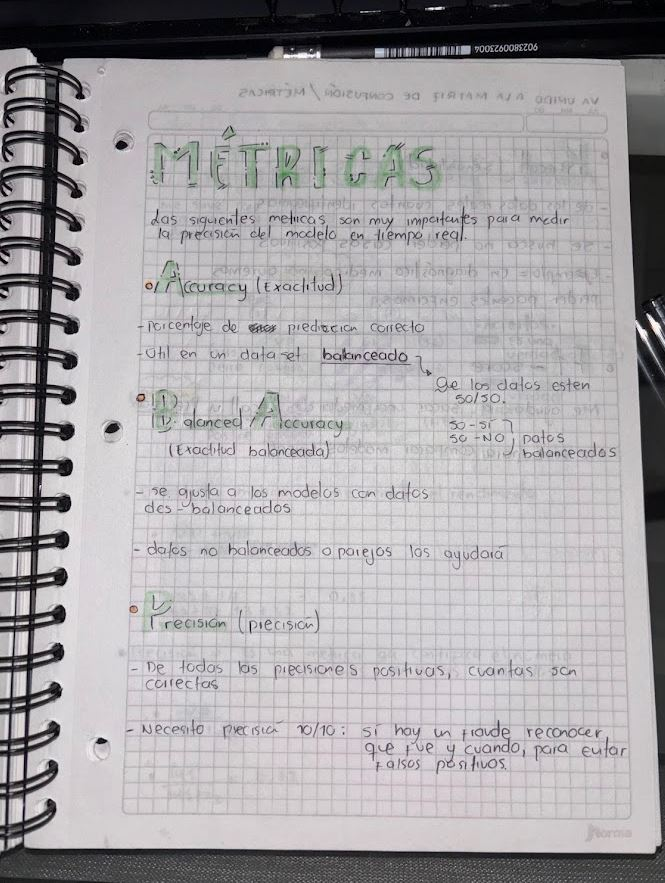


───────────────────────────────────────────────────────
 📄 Respuesta del agente multimodal (Qwen 2.5 VL - OCR):
───────────────────────────────────────────────────────
  Prompt utilizado : Read all the text in this image.
  Texto detectado  :

MÉTRICAS
Las siguientes medicías son muy importantes para medir la precisión del modelo en tiempo real.
Accuracy (Exactitud)
Porcentaje de predicción correcta Util en un dataset balanceado
De los datos esten 50/50.
Balance Accuracy (Exactitud balanceada)
se ajusta a los modelos con datos des balanceados
dales no balanceados o parejos los ayudará
Precision (precisión)
De todos las prediciones positivas, cuantas son correctas
Necesita precisión 10/10: si hay un modelo reconocer que fue y cuando, para eutar falsos positivos.


In [16]:
def response_generation_qwen(image_path, prompt, max_new_tokens=1024):
    """
    Pipeline multimodal: Imagen + Texto (Prompt) → Texto

    Pasos:
      1. Carga y muestra la imagen (resolución original preservada).
      2. Construye un mensaje de chat estructurado con imagen + pregunta explícita.
      3. Genera la respuesta con Qwen2.5-VL.
    """
    # ── 1. Imagen ─────────────────────────────────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    print(f" Resolución original: {image.size[0]}×{image.size[1]} px  "
          f"(Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)")
    display(image)

    # ── 2. Construcción del mensaje de chat ───────────────────────────────────
    # Qwen usa un formato de mensajes estructurado (similar a ChatGPT)
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": prompt}  # <-- Usamos el prompt escrito directamente
        ]
    }]

    # apply_chat_template añade los tokens especiales del formato de chat de Qwen
    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # process_vision_info extrae y preprocesa las imágenes del mensaje
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text_prompt],
        images=image_inputs,
        return_tensors="pt"
    ).to(model.device)

    # ── 3. Generación ─────────────────────────────────────────────────────────
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False  # greedy decoding: determinista y reproducible
        )

    # Decodificar solo los tokens nuevos (excluir el prompt de entrada)
    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)

    # ── 4. Resultado ──────────────────────────────────────────────────────────
    print("\n" + "─"*55)
    print(" 📄 Respuesta del agente multimodal (Qwen 2.5 VL - OCR):")
    print("─"*55)
    print(f"  Prompt utilizado : {prompt}")
    print(f"  Texto detectado  :\n\n{answer}")


# ---------------------------------------------------------
# EJECUCIÓN DE LA PRUEBA OCR
# ---------------------------------------------------------
image_path = "/kaggle/input/datasets/bryanyamacruz/actividad-2/hoja.JPG"
prompt_ocr = "Read all the text in this image."

# Llamada a la función (sin audio)
response_generation_qwen(
    image_path=image_path,
    prompt=prompt_ocr,
    max_new_tokens=1024 # Aumentado para permitir lectura de textos largos
)

# Respuesta

**Resultado de Extracción OCR (BLIP-2):**
Utilizando este modelo, analizó la imagen y describió lo que estaba pasando en ella, pero no dio información sobre el documento. Solamente dio una respuesta descriptiva:

Prompt utilizado: Read all the text in this image.
Texto detectado: a notebook with a pen and pencil


**Respuesta del agente multimodal (Qwen 2.5 VL - OCR):**
Mientras que este modelo sí tomó información sobre los documentos:

Prompt utilizado: Read all the text in this image.
Texto detectado: MÉTRICAS Las siguientes medicías son muy importantes para medir la precisión del modelo en tiempo real. Accuracy (Exactitud) Porcentaje de predicción correcta Util en un datase

Incluso fue más rápido para la toma de los datos.

3. Conversación iterativa con la imagen

    Sube **una imagen de tu elección** y utilízala con el modelo **Qwen-VL**. Realiza una primera pregunta general sobre la imagen, por ejemplo: *“What objects appear in this image?”*. Luego formula una segunda pregunta relacionada con la respuesta anterior y finalmente una tercera pregunta que dependa del contexto.

    Observa si el modelo mantiene el contexto entre las preguntas. **¿Las respuestas son coherentes entre sí? ¿El modelo recuerda la información de turnos anteriores? Escribe una breve conclusión sobre el comportamiento del modelo en una conversación iterativa.**

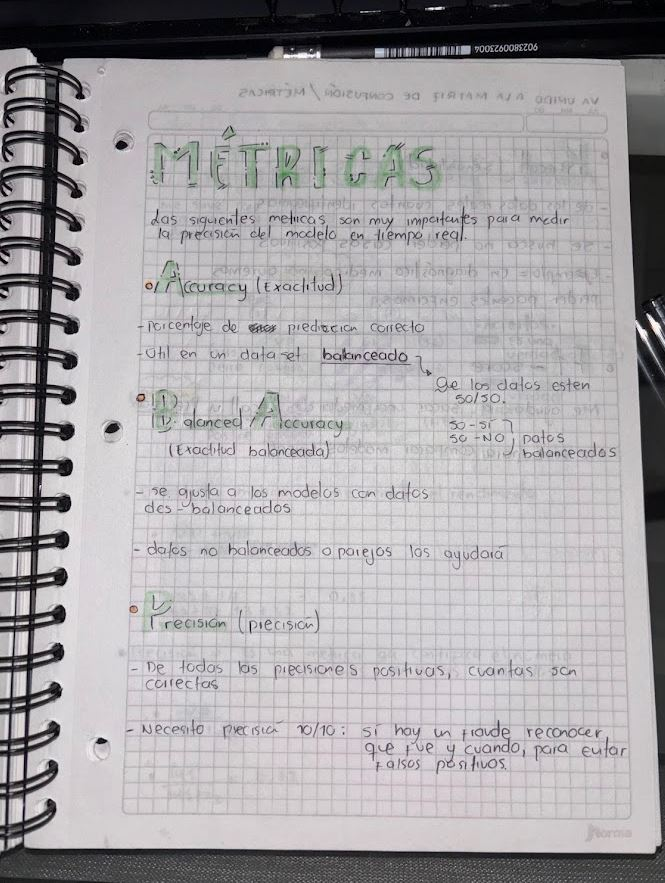


 (Persona) Turno 1 — Pregunta : What objects appear in this image?
 (Maquina) Turno 1 — Respuesta: The image shows a page from a notebook with handwritten notes in Spanish. The title of the page is "MÉTRICAS," which translates to "Metrics" in English. The content appears to be about measuring accuracy and precision in predictive models, particularly in the context of balanced datasets.

Key points on the page include:
- Accuracy (Exactitude)
  - Percentage of correct predictions
  - Useful in unbalanced datasets
  - Example: If all data are 50/50.
-Accuracy Precision
Balanced Accuracy
 
  - Exactitude balancedada)
  - Useful for models with balanced datasets
  - Data not balanced or imbalanced help
- Precision (Precision)
  - Of all positive predictions, how many are correct?
  - Need precision  10/10: if you can recognize what it is and when, to eliminate false positives.

The handwriting is legible and the contents are clear, making the information easy to read.

 (Persona) Turno 2 

In [17]:
# Cambia esta ruta por la de cualquier imagen que quieras usar de tus datasets
image_path_iterative = "/kaggle/input/datasets/bryanyamacruz/actividad-2/hoja.JPG" # O cualquier otra que prefieras

# Las 3 preguntas encadenadas
questions_iterative = [
    "What objects appear in this image?",
    "Which of those objects is the most prominent and why?",
    "Based on your previous answer, what can you infer about the scene or situation shown in the image?"
]

# Llamamos a nuestra nueva función
multiturn_chat(
    image_path=image_path_iterative,
    questions=questions_iterative
)

# Respuesta N°3

**Qwen 2.5 VL**

el modelo demostró una excelente capacidad para mantener el contexto a lo largo de la conversación. Al realizar la segunda y tercera pregunta, Qwen-VL recordó perfectamente la información y los objetos identificados en los turnos anteriores, sin necesidad de que yo volviera a especificar de qué estábamos hablando.


Las respuestas fueron totalmente coherentes entre sí. El modelo logró encadenar sus argumentos de manera lógica; cada nueva respuesta se construyó sobre la base de su contestación anterior, logrando una interacción fluida y no un conjunto de respuestas aisladas.